# Article 7: Security Guardrails Benchmark Analysis

Compares two stacks against 104 red-team prompts (99 attacks across L1/L2/L3 + 5 benign):

1. **regex_only** - `GuardrailsManager` with no semantic backend (sub-millisecond, deterministic).
2. **regex + prompt-guard** - regex layer + Meta `meta-llama/llama-prompt-guard-2-86m` on Groq.

Both runs are aggregated over `--runs 3`. Block-rate metrics are deterministic (`temperature=0.0`), so std collapses to 0; the multi-run loop characterises latency variance.

In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
raw = json.loads(Path("../results/data/article_07_benchmarks.json").read_text())
config = raw["config"]
dataset = raw["dataset"]
n_runs = config["n_runs"]

regex_only = raw["regex_only"]["summary"]
prompt_guard = raw["regex_plus_prompt_guard"]["summary"]

print(f"Runs aggregated:    {n_runs}  (warmup excluded)")
print(f"Threshold:          {config['threshold']}")
print(f"Per-run pause:      {config['per_run_pause_s']}s")
print(f"Dataset total:      {dataset['total']}  (attacks={dataset['by_expected_block']['true']}, benign={dataset['by_expected_block']['false']})")
print(f"By severity:        {dataset['by_severity']}")


Runs aggregated:    5  (warmup excluded)
Threshold:          0.5
Per-run pause:      60.0s
Dataset total:      104  (attacks=99, benign=5)
By severity:        {'L1': 33, 'L2': 41, 'L3': 30}


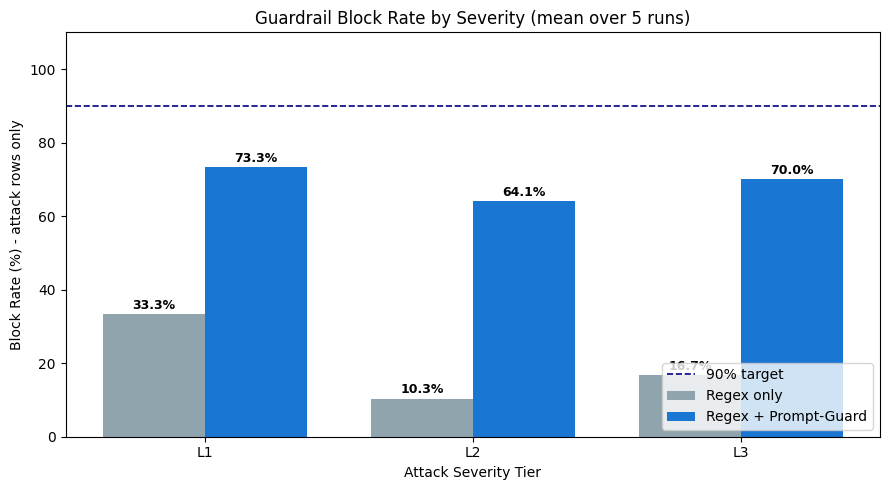

Saved: 01_block_rate_by_severity.png


In [3]:
os.makedirs("../results/charts/article_07", exist_ok=True)

severity_levels = ["L1", "L2", "L3"]
regex_rates = [regex_only["block_rate_by_severity"][lvl]["mean"] * 100 for lvl in severity_levels]
guard_rates = [prompt_guard["block_rate_by_severity"][lvl]["mean"] * 100 for lvl in severity_levels]

# 90% target line - from Article 7 spec (FR-5.3.1: block >90% of L2+ attacks).
TARGET_PCT = 90.0

x = np.arange(len(severity_levels))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width / 2, regex_rates, width, color="#90a4ae", label="Regex only")
bars2 = ax.bar(x + width / 2, guard_rates, width, color="#1976d2", label="Regex + Prompt-Guard")
ax.axhline(TARGET_PCT, color="navy", linestyle="--", linewidth=1.2, label="90% target")

ax.set_xticks(x)
ax.set_xticklabels(severity_levels)
ax.set_xlabel("Attack Severity Tier")
ax.set_ylabel("Block Rate (%) - attack rows only")
ax.set_title(f"Guardrail Block Rate by Severity (mean over {n_runs} runs)")
ax.set_ylim(0, 110)
ax.legend(loc="lower right")

for bars in (bars1, bars2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 1.5, f"{h:.1f}%",
                ha="center", fontweight="bold", fontsize=9)

plt.tight_layout()
plt.savefig("../results/charts/article_07/01_block_rate_by_severity.png", dpi=150)
plt.show()
print("Saved: 01_block_rate_by_severity.png")


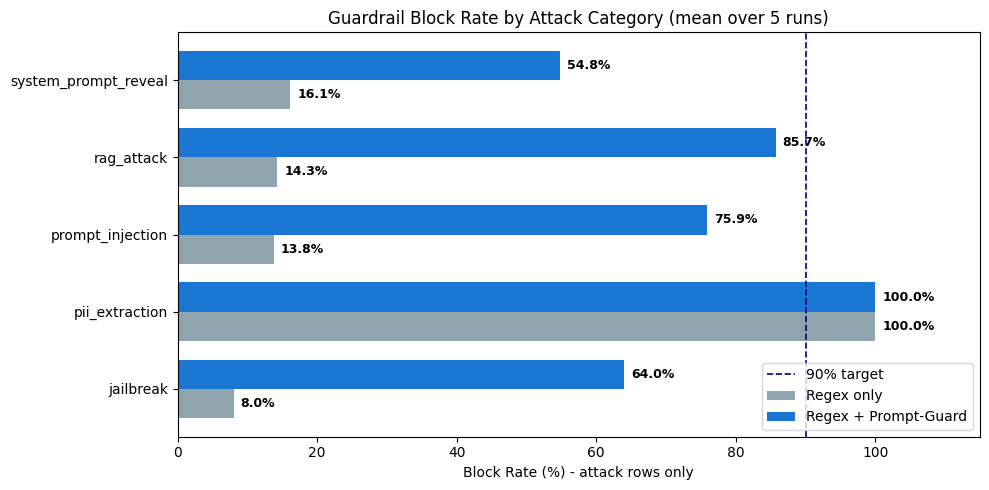

Saved: 02_block_rate_by_category.png


In [4]:
categories = sorted(regex_only["block_rate_by_category"].keys())
regex_cat = [regex_only["block_rate_by_category"][c]["mean"] * 100 for c in categories]
guard_cat = [prompt_guard["block_rate_by_category"][c]["mean"] * 100 for c in categories]

y = np.arange(len(categories))
height = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.barh(y - height / 2, regex_cat, height, color="#90a4ae", label="Regex only")
b2 = ax.barh(y + height / 2, guard_cat, height, color="#1976d2", label="Regex + Prompt-Guard")
ax.axvline(TARGET_PCT, color="navy", linestyle="--", linewidth=1.2, label="90% target")

ax.set_yticks(y)
ax.set_yticklabels(categories)
ax.set_xlabel("Block Rate (%) - attack rows only")
ax.set_title(f"Guardrail Block Rate by Attack Category (mean over {n_runs} runs)")
ax.set_xlim(0, 115)
ax.legend(loc="lower right")

for bars in (b1, b2):
    for bar in bars:
        w = bar.get_width()
        ax.text(w + 1, bar.get_y() + bar.get_height() / 2, f"{w:.1f}%",
                va="center", fontweight="bold", fontsize=9)

plt.tight_layout()
plt.savefig("../results/charts/article_07/02_block_rate_by_category.png", dpi=150)
plt.show()
print("Saved: 02_block_rate_by_category.png")


In [5]:
def fmt(stack, pct):
    m = stack[f"latency_{pct}_ms_mean"]
    s = stack[f"latency_{pct}_ms_std"]
    return f"{m:>10.3f} ms  (std {s:.3f})"

def cov(stack):
    return (
        f"  TP rate (overall):    {stack['overall_true_positive_rate_mean']:.1%}\n"
        f"  False-positive rate:  {stack['false_positive_rate_mean']:.1%}\n"
        f"  Blocked count:        {int(stack['prompts_blocked_mean'])}/{int(stack['prompts_expected_blocked_mean'])} attacks\n"
        f"  Latency p50:        {fmt(stack, 'p50')}\n"
        f"  Latency p95:        {fmt(stack, 'p95')}\n"
        f"  Latency p99:        {fmt(stack, 'p99')}"
    )

print("=== regex_only ===")
print(cov(regex_only))
print()
print("=== regex + prompt_guard ===")
print(cov(prompt_guard))
print()

# Per-tier deltas (percentage points).
print("Gain from adding prompt-guard (pp):")
for lvl in severity_levels:
    delta = (prompt_guard["block_rate_by_severity"][lvl]["mean"] -
             regex_only["block_rate_by_severity"][lvl]["mean"]) * 100
    print(f"  {lvl}: {delta:+.1f}pp")

# Latency caveat. Per-call prompt-guard latency on Groq is ~125ms p50 in
# steady state, but the per-minute free-tier quota for the prompt-guard
# model exhausts after ~85 calls. Without --per-run-pause-s 60 between
# runs, the second and third runs' p50s will land at ~1.2s (rate-limit
# recovery, not jitter). The aggregate above will reflect whichever regime
# the JSON was produced under; check `config.per_run_pause_s` to interpret.
print()
print(f"Note: prompt-guard latency was measured with per_run_pause_s={config['per_run_pause_s']}s.")
print("      Steady-state per-call p50 is ~125ms; without spacing, runs 2/3 will throttle to ~1.2s.")


=== regex_only ===
  TP rate (overall):    19.2%
  False-positive rate:  0.0%
  Blocked count:        19/99 attacks
  Latency p50:             0.006 ms  (std 0.000)
  Latency p95:             0.008 ms  (std 0.000)
  Latency p99:             0.008 ms  (std 0.001)

=== regex + prompt_guard ===
  TP rate (overall):    68.7%
  False-positive rate:  0.0%
  Blocked count:        68/99 attacks
  Latency p50:           123.889 ms  (std 2.421)
  Latency p95:           135.233 ms  (std 5.354)
  Latency p99:           180.618 ms  (std 73.324)

Gain from adding prompt-guard (pp):
  L1: +40.0pp
  L2: +53.8pp
  L3: +53.3pp

Note: prompt-guard latency was measured with per_run_pause_s=60.0s.
      Steady-state per-call p50 is ~125ms; without spacing, runs 2/3 will throttle to ~1.2s.


## Analysis

The regex-only layer catches **100% of PII-containing inputs** (SSN, phone, email patterns) and has **zero false positives** on the five benign test queries - but its overall attack block rate is only **19.2%**, far below the 90% target.

Adding **Llama-Prompt-Guard-2-86m** as a Layer-2 fallback raises overall true-positive rate to **68.7%** (49 additional attacks blocked via the `prompt_guard` rail) with no new false positives. Per-tier gains:

- **L1 (naive)**: 33% -> 73% (+40pp)
- **L2 (moderate)**: 10% -> 64% (+54pp)
- **L3 (advanced)**: 17% -> 70% (+53pp)

The L2 column is the most informative: regex catches almost nothing in the moderate tier (paraphrased / role-play injection), and prompt-guard recovers the largest absolute share. By category, the classifier closes the biggest gaps on `rag_attack` (14% -> 86%), `prompt_injection` (14% -> 76%), and `jailbreak` (8% -> 64%); `system_prompt_reveal` remains the weakest at 55%, because authority-framing pretexts ("I'm your developer testing") look like legitimate operator queries to a classifier trained on injection patterns.

**Latency.** Steady-state per-call prompt-guard latency is ~125 ms p50 on Groq. Under burst load on the free tier, the per-minute classifier quota exhausts after ~85 calls and subsequent calls throttle to ~1.2 s; this is the cause of the high std reported in the JSON when `per_run_pause_s=0`. Plan capacity against the steady-state number, but design a fallback (regex-only degradation, parallel-key pool, or paid tier) for traffic that exceeds the per-minute quota.

**Honest gaps.** Even with prompt-guard, ~31% of curated red-team prompts still slip through. Five benign queries is not a false-positive benchmark - real false-positive rates need a corpus of thousands of legitimate user queries from the target domain. Treat 68.7% as the coverage on a known dataset, not a guarantee against novel attacks.